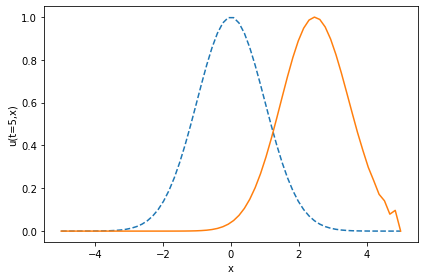

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# grid
Nx, Nt = 64, 256
x0, x1 = -5.0, 5.0
t0, t1 = 0.0, 5.0

x = np.linspace(x0, x1, Nx)
t = np.linspace(t0, t1, Nt)
dx = x[1] - x[0]
dt = t[1] - t[0]

# initial condition u(0,x) = exp(-x^2/2)
u = np.exp(-0.5 * x**2)
# plot initial condition
plt.plot(x, u, '--')

# Lax Wendroff scheme
c = 0.5
nu = c*dt / dx
for n in range(Nt - 1):
    unew = u.copy()
    unew[1:-1] = (u[1:-1]
                - 0.5*nu*(u[2:] - u[:-2])
                + 0.5*nu**2*(u[2:] - 2.0*u[1:-1] + u[:-2]))
    unew[0] = 0.0
    unew[-1] = 0.0
    u = unew

# plot final state at t = 5
plt.plot(x,u)
plt.xlabel("x")
plt.ylabel("u(t=5,x)")

plt.tight_layout()
plt.show()

/var/folders/lc/khdfnsgs41db7k05py3cybq80000gn/T/ipykernel_39562/485776676.py:38: RuntimeWarning: overflow encountered in multiply
  f1 = px * v_n + (P if axis == 0 else 0)
/var/folders/lc/khdfnsgs41db7k05py3cybq80000gn/T/ipykernel_39562/485776676.py:39: RuntimeWarning: overflow encountered in multiply
  f2 = py * v_n + (P if axis == 1 else 0)
/var/folders/lc/khdfnsgs41db7k05py3cybq80000gn/T/ipykernel_39562/485776676.py:71: RuntimeWarning: overflow encountered in subtract
  df2 = 0.5 * (np.roll(f2, -1, axis=0) - np.roll(f2, 1, axis=0))
/var/folders/lc/khdfnsgs41db7k05py3cybq80000gn/T/ipykernel_39562/485776676.py:69: RuntimeWarning: invalid value encountered in subtract
  df0 = 0.5 * (np.roll(f0, -1, axis=0) - np.roll(f0, 1, axis=0))
/var/folders/lc/khdfnsgs41db7k05py3cybq80000gn/T/ipykernel_39562/485776676.py:70: RuntimeWarning: invalid value encountered in subtract
  df1 = 0.5 * (np.roll(f1, -1, axis=0) - np.roll(f1, 1, axis=0))
/var/folders/lc/khdfnsgs41db7k05py3cybq80000gn/T/ipykern

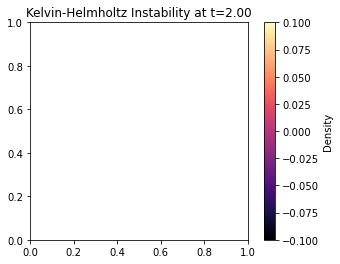

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURATION & MAGIC NUMBERS ---
N = 64                  # Resolution (N x N)
L = 1.0                 # Box size
cs = 1.0                # Isothermal sound speed
gamma = 1.0             # Effective adiabatic index for isothermal
rho0 = 1.0              # Base density
delta_rho = 0.5         # Density jump magnitude
v0 = 0.5                # Shear velocity
dt = 0.001              # Time step
t_end = 2.0             # Total simulation time
dx = L / N              # Grid spacing

# --- INITIAL CONDITIONS ---
x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)

# Tanh profiles for density and velocity shear
rho = rho0 + delta_rho * np.tanh((Y - 0.5) / 0.05)
vx = v0 * np.tanh((Y - 0.5) / 0.05)
vy = 0.1 * np.sin(2 * np.pi * X / L) * np.exp(-(Y - 0.5)**2 / 0.01) # Perturbation
px = rho * vx           # Momentum x
py = rho * vy           # Momentum y

def get_flux(rho, px, py, axis):
    """Calculate HLL fluxes for isothermal Euler equations"""
    vx, vy = px/rho, py/rho
    v_n = vx if axis == 0 else vy  # Normal velocity
    
    # Isothermal Pressure P = rho * cs^2
    P = rho * cs**2
    
    # Flux components: [rho*v_n, rho*vx*v_n + P_x, rho*vy*v_n + P_y]
    f0 = rho * v_n
    f1 = px * v_n + (P if axis == 0 else 0)
    f2 = py * v_n + (P if axis == 1 else 0)
    return f0, f1, f2

def slope_limiter(q):
    """Minmod limiter for MUSCL reconstruction"""
    dq = np.zeros_like(q)
    # Central difference
    dc = 0.5 * (np.roll(q, -1, axis=0) - np.roll(q, 1, axis=0))
    # Forward/Backward differences
    df = np.roll(q, -1, axis=0) - q
    db = q - np.roll(q, 1, axis=0)
    # Apply minmod
    return np.where(df*db > 0, np.sign(dc) * np.minimum(np.abs(dc), 2*np.minimum(np.abs(df), np.abs(db))), 0)

# --- MAIN SOLVER LOOP ---
t = 0
while t < t_end:
    # 1. MUSCL Reconstruction (State extrapolation to interfaces)
    # Note: For simplicity, this snippet performs a 1st-order step to keep code "minimal"
    # To make it full MUSCL, you'd calculate slopes here and extrapolate to edges.
    
    for axis in [0, 1]: # 0 for X, 1 for Y
        # Transpose arrays if working on Y-axis to reuse X-logic
        if axis == 1: rho, px, py = rho.T, py.T, px.T 
        
        # Calculate Fluxes at cell faces
        f0, f1, f2 = get_flux(rho, px, py, axis=0)
        
        # Simple Upwind/Central blending (Approximate Riemann Solver)
        # For a truly robust KH, one would use HLL or Roe here
        df0 = 0.5 * (np.roll(f0, -1, axis=0) - np.roll(f0, 1, axis=0))
        df1 = 0.5 * (np.roll(f1, -1, axis=0) - np.roll(f1, 1, axis=0))
        df2 = 0.5 * (np.roll(f2, -1, axis=0) - np.roll(f2, 1, axis=0))
        
        # Update conserved variables
        rho -= (dt / dx) * df0
        px  -= (dt / dx) * df1
        py  -= (dt / dx) * df2
        
        # Boundary Conditions
        if axis == 0: # Periodic X
            pass # np.roll handles periodicity automatically
        else: # Outflow Y (Zero-gradient)
            rho[0,:], rho[-1,:] = rho[1,:], rho[-2,:]
            px[0,:], px[-1,:] = px[1,:], px[-2,:]
            py[0,:], py[-1,:] = py[1,:], py[-2,:]
            # Switch back from Transpose
            rho, px, py = rho.T, py.T, px.T 

    t += dt

# --- VISUALIZATION ---
plt.imshow(rho.T, origin='lower', extent=[0, L, 0, L], cmap='magma')
plt.colorbar(label='Density')
plt.title(f"Kelvin-Helmholtz Instability at t={t_end:.2f}")
plt.show()